# Advanced EDA and Feature Engineering

**Dataset:** Online order data  
**Project:** DecodeLabs Data Science Project 1

The aim of this notebook is to clean the raw data, study its main patterns, handle missing values and outliers, and create useful features for future machine-learning work.

## Importing libraries and load the dataset



In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

file_path = 'Dataset_for_Data_Analytics.xlsx'
df = pd.read_excel(file_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 2. Initial inspection

In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print()
print('Column names:')
print(df.columns.tolist())

print()
print('Data types:')
df.dtypes

Rows: 1200
Columns: 14

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:


OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [4]:

duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


## 3. Missing-value analysis

First, I calculated both the number and percentage of missing values. This is more useful than only checking `isnull().sum()` because the percentage helps in choosing a treatment method.

In [ ]:
missing_summary = pd.DataFrame({
'Missing Values': df.isnull().sum(),
'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Missing Percentage
CouponCode,309,25.75


## 4. Univariate exploratory analysis

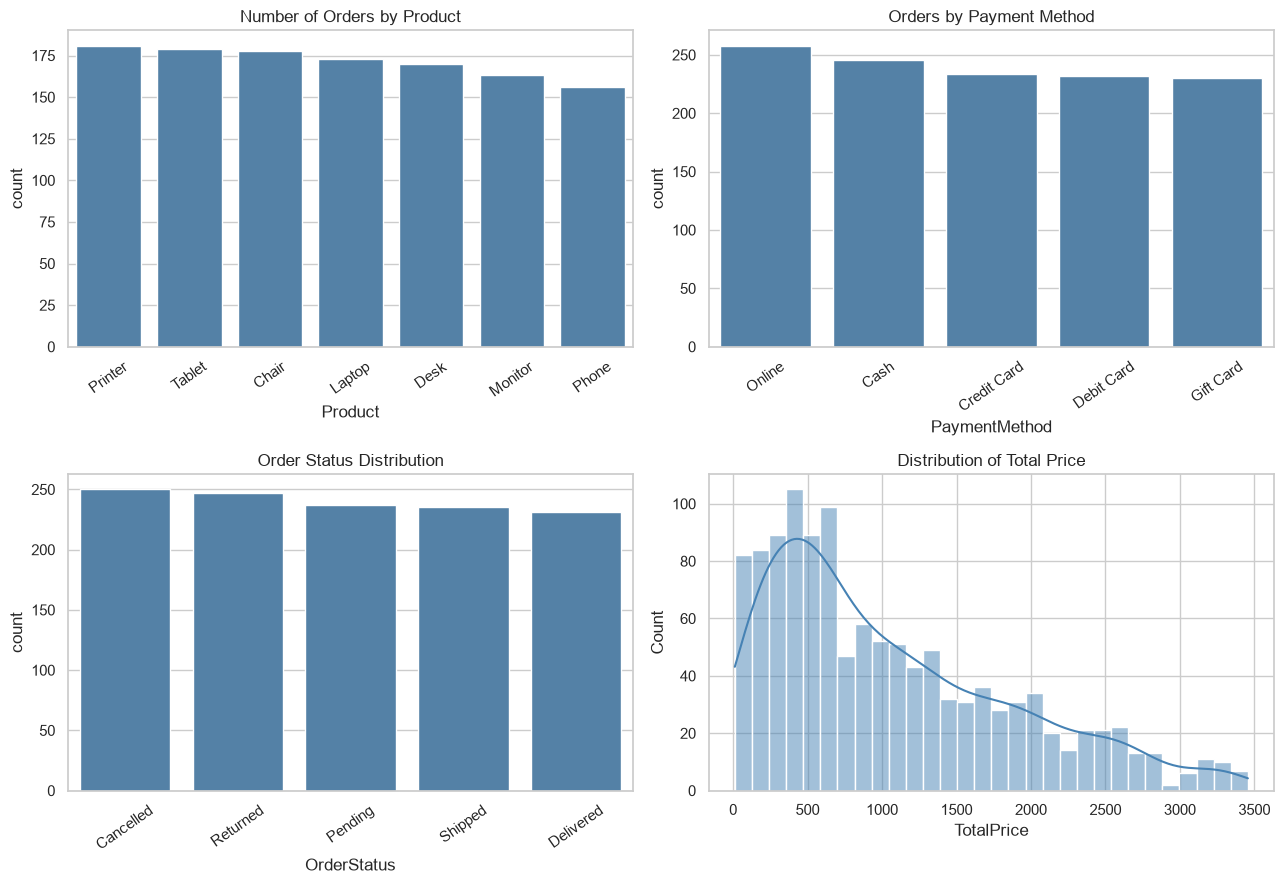

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=df, x='Product', order=df['Product'].value_counts().index, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Number of Orders by Product')
axes[0, 0].tick_params(axis='x', rotation=35)

sns.countplot(
data=df,
x='PaymentMethod', 
order=df['PaymentMethod'].value_counts().index, 
ax=axes[0, 1], color='steelblue')

axes[0, 1].set_title('Orders by Payment Method')
axes[0, 1].tick_params(axis='x', rotation=35)

sns.countplot(data=df, x='OrderStatus', order=df['OrderStatus'].value_counts().index, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Order Status Distribution')
axes[1, 0].tick_params(axis='x', rotation=35)

sns.histplot(data=df, x='TotalPrice', bins=30, kde=True, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Distribution of Total Price')

plt.tight_layout()
plt.show()

## 5. Bivariate analysis

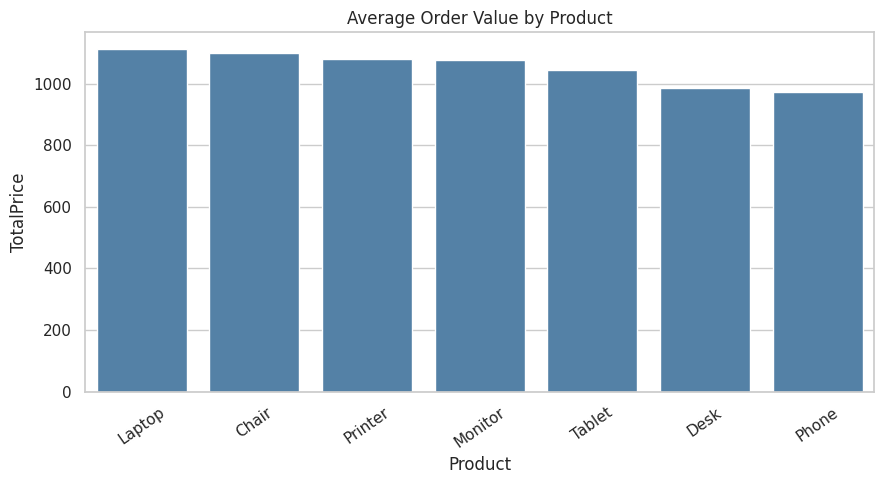

,Product,TotalPrice
2,Laptop,1110.558150
0,Chair,1098.989382
5,Printer,1080.732652
3,Monitor,1077.616012
6,Tablet,1042.284637
1,Desk,985.058412
4,Phone,972.579423


In [ ]:

product_value = (
df.groupby('Product', as_index=False)['TotalPrice']
.mean()
.sort_values('TotalPrice', ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=product_value, x='Product', y='TotalPrice', color='steelblue')
plt.title('Average Order Value by Product')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

product_value

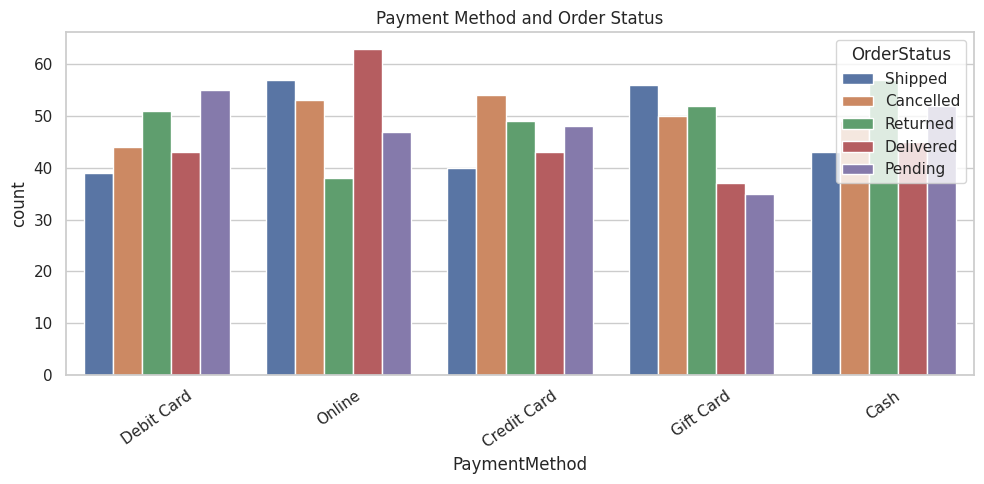

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='OrderStatus')
plt.title('Payment Method and Order Status')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

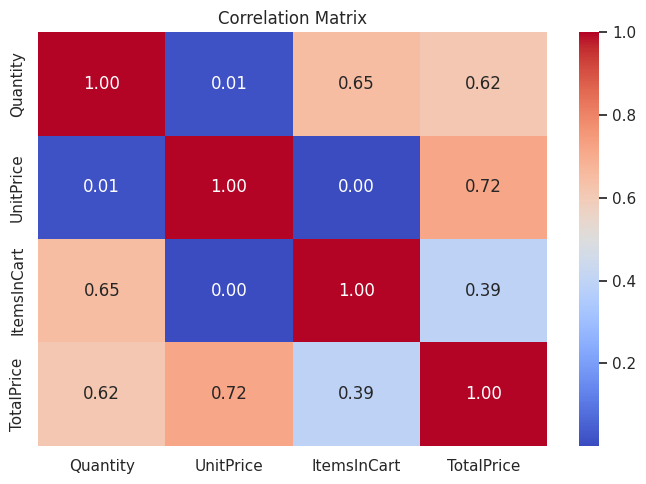

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [ ]:

numeric_columns = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

correlation_matrix

## 6. Outlier detection using IQR

The Interquartile Range method is applied to every numerical column. It is less sensitive to skewed data than a mean-based rule.

In [ ]:
def iqr_outlier_summary(data, columns):
    rows = []
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
        rows.append({
         'Column': column,
         'Q1': round(q1, 2),
         'Q3': round(q3, 2),
        'Lower Bound': round(lower_bound, 2),
      'Upper Bound': round(upper_bound, 2),
        'Outlier Count': int(outlier_count)
        })
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, numeric_columns)
outlier_summary

,Column,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Quantity,2.00,4.00,-1.00,7.00,0
1,UnitPrice,186.06,521.57,-317.20,1024.83,0
2,ItemsInCart,4.00,7.00,-0.50,11.50,0
3,TotalPrice,410.52,1578.48,-1341.41,3330.41,8


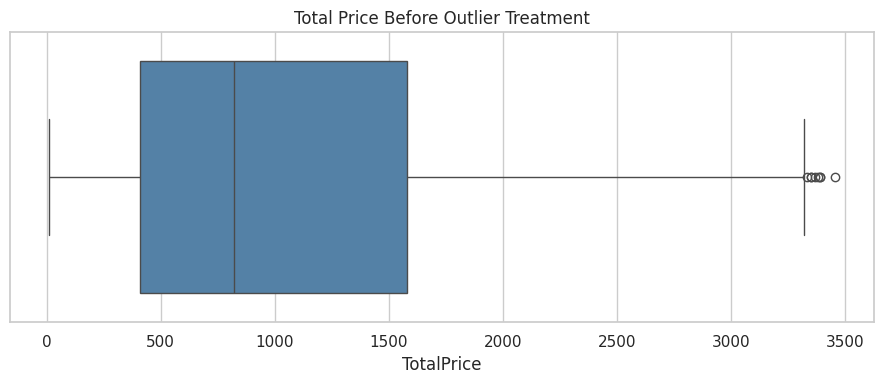

In [ ]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='TotalPrice', color='steelblue')
plt.title('Total Price Before Outlier Treatment')
plt.tight_layout()
plt.show()

The high `TotalPrice` values are possible business transactions rather than obvious data-entry errors. Therefore, I did not delete any rows. Instead, I used **winsorization (capping)** and stored the result in a new column. This preserves all 1,200 records and keeps the original `TotalPrice` available for auditing.

In [ ]:
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


df['TotalPrice_Capped'] = np.clip(df['TotalPrice'], lower_bound, upper_bound)

print('Lower bound:', round(lower_bound, 2))
print('Upper bound:', round(upper_bound, 2))
print('Values capped:', (df['TotalPrice'] != df['TotalPrice_Capped']).sum())

Lower bound: -1341.41
Upper bound: 3330.41
Values capped: 8


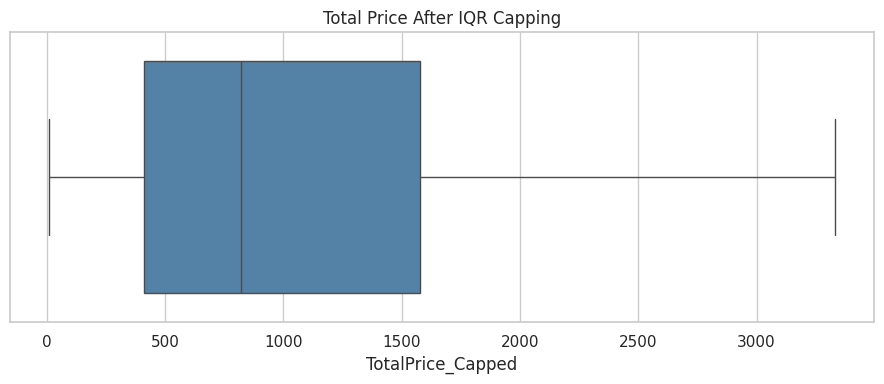

In [ ]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x='TotalPrice_Capped', color='steelblue')
plt.title('Total Price After IQR Capping')
plt.tight_layout()
plt.show()

## 7. Feature engineering


In [ ]:
# Ensure the date column has datetime format
df['Date'] = pd.to_datetime(df['Date'])

df['OrderMonth'] = df['Date'].dt.month
df['OrderDayOfWeek'] = df['Date'].dt.day_name()
df['IsWeekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

# The missing indicator was made before imputation, so 1 means no coupon was recorded
df['UsedCoupon'] = (1 - df['CouponWasMissing']).astype(int)

# Avoid division by zero, although this dataset has no zero value in ItemsInCart
df['CartConversionRatio'] = np.where(
    df['ItemsInCart'] > 0,
    df['Quantity'] / df['ItemsInCart'],
    0
).round(3)

df['OrderValueCategory'] = pd.qcut(
    df['TotalPrice_Capped'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

df['TotalPrice_Log'] = np.log1p(df['TotalPrice_Capped'])

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponWasMissing,TotalPrice_Capped,OrderMonth,OrderDayOfWeek,IsWeekend,UsedCoupon,CartConversionRatio,OrderValueCategory,TotalPrice_Log
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,0,2853.10,1,Wednesday,0,1,0.714,High,7.956512
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,0,302.70,8,Friday,0,1,0.667,Low,5.716040
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,0,2753.40,2,Tuesday,0,1,0.625,High,7.920955
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,0,273.19,10,Sunday,1,1,0.200,Low,5.613821
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,0,2504.04,5,Thursday,0,1,0.500,High,7.826060


## 8. Checking Validation 

In [ ]:
validation_results = {
    'Total rows': len(df),
    'Duplicate rows': int(df.duplicated().sum()),
    'Missing values remaining': int(df.isnull().sum().sum()),
    'Unique Order IDs': int(df['OrderID'].nunique()),
    'Negative quantities': int((df['Quantity'] < 0).sum()),
    'Negative unit prices': int((df['UnitPrice'] < 0).sum()),
    'Negative total prices': int((df['TotalPrice'] < 0).sum())
}

pd.Series(validation_results, name='Result')

Total rows                  1200
Duplicate rows                 0
Missing values remaining       0
Unique Order IDs            1200
Negative quantities            0
Negative unit prices           0
Negative total prices          0
Name: Result, dtype: int64

In [ ]:

price_difference = (df['Quantity'] * df['UnitPrice'] - df['TotalPrice']).abs()
print('Rows where Quantity × UnitPrice does not match TotalPrice:', (price_difference > 0.01).sum())

Rows where Quantity × UnitPrice does not match TotalPrice: 0


## 9. Main findings

In [ ]:
print('Most ordered product:', df['Product'].value_counts().idxmax())
print('Most common payment method:', df['PaymentMethod'].value_counts().idxmax())
print('Most common order status:', df['OrderStatus'].value_counts().idxmax())
print('Average order value:', round(df['TotalPrice'].mean(), 2))
print('Median order value:', round(df['TotalPrice'].median(), 2))
print('Weekend order percentage:', round(df['IsWeekend'].mean() * 100, 2), '%')
print('Coupon usage percentage:', round(df['UsedCoupon'].mean() * 100, 2), '%')

Most ordered product: Printer
Most common payment method: Online
Most common order status: Cancelled
Average order value: 1053.97
Median order value: 823.62
Weekend order percentage: 29.83 %
Coupon usage percentage: 74.25 %


## 10. Save the cleaned dataset

The prepared file contains the original columns plus the engineered features. The raw `TotalPrice` is retained, while `TotalPrice_Capped` can be used by models that are sensitive to extreme values.

In [ ]:
output_file = 'cleaned_orders_with_features.csv'
df.to_csv(output_file, index=False)
print('Saved:', output_file)
print('Final shape:', df.shape)

Saved: cleaned_orders_with_features.csv
Final shape: (1200, 23)


## Conclusion

The dataset was already structurally strong: it had no duplicate rows, valid identifiers, and no missing numerical values. The main cleaning issue was the missing categorical coupon field. After imputation, IQR-based outlier treatment, validation, and feature engineering, the final dataset is ready for the next stage of analysis or modelling.